# 06 - Forecasting Models

**Purpose:** compare baselines and scikit-learn models for two tasks:

- next-month review-count regression;
- attention-pulse classification.

In [1]:
# Imports
from pathlib import Path
import contextlib
import io
import json
import os
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Project paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Input files
FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"

# Output files
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"
PULSE_TOPK_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_topk_metrics.csv"
PULSE_CALIBRATION_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_calibration.csv"

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Load data
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]

print(modeling.shape)
modeling.head()

(40822, 111)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number,pulse_baseline_reviews,pulse_relative_lift,attention_pulse,first_active_feature_month_str
0,-1XSzguS6XLN-V6MVZMg2A,6,29.0,6,2.000000,1.000000,0.0,6,29.0,4.833333,...,2015-12,2016-01,12,-2.449294e-16,1.000000e+00,12,1.000000,6.000000,1,2015-12
1,-1XSzguS6XLN-V6MVZMg2A,6,30.0,6,4.000000,2.000000,0.0,12,59.0,4.916667,...,2016-01,2016-02,1,5.000000e-01,8.660254e-01,13,2.000000,8.500000,1,2015-12
2,-1XSzguS6XLN-V6MVZMg2A,17,84.0,17,9.666667,4.833333,0.0,29,143.0,4.931034,...,2016-02,2016-03,2,8.660254e-01,5.000000e-01,14,4.833333,2.896552,1,2015-12
3,-1XSzguS6XLN-V6MVZMg2A,14,67.0,14,12.333333,7.166667,0.0,43,210.0,4.883721,...,2016-03,2016-04,3,1.000000e+00,6.123234e-17,15,7.166667,2.790698,1,2015-12
4,-1XSzguS6XLN-V6MVZMg2A,20,97.0,20,17.000000,10.500000,0.0,63,307.0,4.873016,...,2016-04,2016-05,4,8.660254e-01,-5.000000e-01,16,10.500000,1.142857,0,2015-12


## Chronological Split

The modeling question is restricted to normal monthly review activity in the pre-COVID period. The evaluation split uses three chronological periods:

- **train:** 2015-2017, used to fit the model;
- **validation:** 2018, used only for attention-pulse threshold tuning;
- **test:** 2019, used for final reported performance.

This keeps the final test period in the same operating regime as the training data, so the metrics estimate ordinary pre-COVID forecast performance.

## Feature Groups

Let's try to compare interpretable modality groups: historical review behavior, business metadata, SNA exposure, NLP text signals, and all modalities combined.

## Attention-Pulse Models

Pulse models are evaluated in three ways:

- thresholded classification metrics using a validation-tuned cutoff;
- top-k retrieval metrics, which ask whether the model can surface the most likely 5%, 10%, or 20% of future attention pulses;
- probability diagnostics using Brier score and calibration bins.

Because pulses are rare, F1, PR-AUC, precision@k, recall@k, and calibration are more informative than accuracy alone.

In [2]:
# Metrics
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator


def safe_auc(metric_fn, y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return metric_fn(y_true, score)


def period_label(split, prefix):
    return f"{split[f'{prefix}_start']} to {split[f'{prefix}_end']}"


# Data splits
def split_modeling_data(split):
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    validation_mask = (modeling["target_month_str"] >= split["validation_start"]) & (modeling["target_month_str"] <= split["validation_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    return modeling[train_mask].copy(), modeling[validation_mask].copy(), modeling[test_mask].copy()


# Regression evaluation
def evaluate_regression(split_name, model_name, y_true, y_pred, split):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "split": split_name,
        "task": "review_count_regression",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    }


# Classification metrics
def classification_metric_values(y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(roc_auc_score, y_true, y_score),
        "PR_AUC": safe_auc(average_precision_score, y_true, y_score),
        "Brier": brier_score_loss(y_true, y_score),
    }


# Classification evaluation
def evaluate_classification(
    split_name,
    model_name,
    y_true,
    y_pred,
    y_score,
    split,
    decision_threshold,
    threshold_source,
    validation_metrics=None,
):
    y_true = np.asarray(y_true, dtype=int)
    metrics = classification_metric_values(y_true, y_pred, y_score)
    validation_metrics = validation_metrics or {}
    return {
        "split": split_name,
        "task": "attention_pulse_classification",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "decision_threshold": decision_threshold,
        "threshold_source": threshold_source,
        "validation_precision": validation_metrics.get("precision", np.nan),
        "validation_recall": validation_metrics.get("recall", np.nan),
        "validation_F1": validation_metrics.get("F1", np.nan),
        "validation_Brier": validation_metrics.get("Brier", np.nan),
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC_AUC"],
        "PR_AUC": metrics["PR_AUC"],
        "Brier": metrics["Brier"],
    }


# Tune threshold
def tune_threshold(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        threshold = 0.5
        y_pred = (y_score >= threshold).astype(int)
        return threshold, classification_metric_values(y_true, y_pred, y_score)

    rows = []

    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_score >= threshold).astype(int)
        values = classification_metric_values(y_true, y_pred, y_score)
        rows.append({
            "threshold": threshold,
            "precision": values["precision"],
            "recall": values["recall"],
            "F1": values["F1"],
        })

    threshold_grid = pd.DataFrame(rows)
    best = threshold_grid.sort_values(["F1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    threshold = float(best["threshold"])
    y_pred = (y_score >= threshold).astype(int)

    return threshold, classification_metric_values(y_true, y_pred, y_score)


# Top-k evaluation
def evaluate_top_k(split_name, model_name, y_true, y_score, split, k_values):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score)
    total_positives = int(y_true.sum())
    base_rate = y_true.mean() if len(y_true) else np.nan
    rows = []

    for k_fraction in k_values:
        selected_count = max(1, int(np.ceil(len(y_true) * k_fraction)))
        selected = order[:selected_count]
        selected_positives = int(y_true[selected].sum())
        precision_at_k = selected_positives / selected_count
        recall_at_k = np.nan if total_positives == 0 else selected_positives / total_positives

        rows.append({
            "split": split_name,
            "task": "attention_pulse_top_k",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "k_fraction": k_fraction,
            "selected_rows": selected_count,
            "actual_positives": total_positives,
            "selected_positives": selected_positives,
            "base_positive_rate": base_rate,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "lift_vs_base_rate": np.nan if base_rate == 0 else precision_at_k / base_rate,
        })

    return rows


# Calibration evaluation
def evaluate_calibration(split_name, model_name, y_true, y_score, split, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_score, bin_edges, right=False) - 1, 0, n_bins - 1)
    rows = []

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not mask.any():
            continue

        rows.append({
            "split": split_name,
            "task": "attention_pulse_calibration",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "probability_bin": bin_id,
            "bin_lower": bin_edges[bin_id],
            "bin_upper": bin_edges[bin_id + 1],
            "rows": int(mask.sum()),
            "mean_predicted_probability": float(y_score[mask].mean()),
            "observed_pulse_rate": float(y_true[mask].mean()),
            "brier_score": brier_score_loss(y_true, y_score),
        })

    return rows


# Feature selection size
def selected_k(features, requested=20):
    return min(requested, len(features))


# Regression models
def make_rf_regressor(features):
    return RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=1)


def make_hgb_regressor(features):
    return HistGradientBoostingRegressor(max_iter=180, learning_rate=0.05, l2_regularization=0.05, max_leaf_nodes=31, random_state=42)


def make_poisson_regressor(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", PoissonRegressor(alpha=0.1, max_iter=1000)),
    ])


def make_selected_hgb_regressor(features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_regression, k=selected_k(features))),
        ("model", make_hgb_regressor(features)),
    ])


def make_selected_poisson_regressor(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=selected_k(features))),
        ("model", PoissonRegressor(alpha=0.1, max_iter=1000)),
    ])


# Classification models
def make_rf_classifier(features):
    return RandomForestClassifier(
        n_estimators=140,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    )


def make_hgb_classifier(features):
    return HistGradientBoostingClassifier(max_iter=180, learning_rate=0.05, l2_regularization=0.05, max_leaf_nodes=31, random_state=42)


def make_logistic_classifier(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])


def make_selected_hgb_classifier(features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=selected_k(features))),
        ("model", make_hgb_classifier(features)),
    ])


def make_selected_logistic_classifier(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=selected_k(features))),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])


# Split periods
splits = {
    "normal_pre_covid_test": {
        "train_start": "2015-02",
        "train_end": "2017-12",
        "validation_start": "2018-01",
        "validation_end": "2018-12",
        "test_start": "2019-01",
        "test_end": "2019-12",
    },
}

PULSE_TOP_K_VALUES = [0.05, 0.10, 0.20]

# Feature groups
historical_features = [
    "prev_month_reviews",
    "rolling_3_avg",
    "rolling_6_avg",
    "same_month_previous_year",
    "cumulative_review_count",
    "avg_rating_history",
    "calendar_month",
    "month_sin",
    "month_cos",
    "feature_month_number",
]

business_features = [
    "business_stars",
    "business_review_count",
    "is_restaurant",
    "is_food",
    "is_nightlife",
    "is_tourism",
]

static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]

dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]

sna_features = static_sna_features + dynamic_social_exposure_features

nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]

sentiment_features = [
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
]

tfidf_features = sorted([column for column in modeling.columns if column.startswith("tfidf_recent_")])
nlp_features = nlp_features + sentiment_features + tfidf_features
all_modality_features = historical_features + business_features + sna_features + nlp_features

# Feature sets
feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + SNA": historical_features + sna_features,
    "ML: historical + NLP": historical_features + nlp_features,
    "ML: all modalities": all_modality_features,
}

# Regression specs
regression_model_specs = [
    {"name": name, "features": features, "family": "RandomForestRegressor", "builder": make_rf_regressor}
    for name, features in feature_sets.items()
] + [
    {"name": "ML: HGB all modalities", "features": all_modality_features, "family": "HistGradientBoostingRegressor", "builder": make_hgb_regressor},
    {"name": "ML: Poisson all modalities", "features": all_modality_features, "family": "PoissonRegressor", "builder": make_poisson_regressor},
    {"name": "ML: HGB selected top 20", "features": all_modality_features, "family": "SelectKBest + HistGradientBoostingRegressor", "builder": make_selected_hgb_regressor},
    {"name": "ML: Poisson selected top 20", "features": all_modality_features, "family": "SelectKBest + PoissonRegressor", "builder": make_selected_poisson_regressor},
]

# Classification specs
classification_model_specs = [
    {"name": name, "features": features, "family": "RandomForestClassifier", "builder": make_rf_classifier}
    for name, features in feature_sets.items()
] + [
    {"name": "ML: HGB all modalities", "features": all_modality_features, "family": "HistGradientBoostingClassifier", "builder": make_hgb_classifier},
    {"name": "ML: Logistic all modalities", "features": all_modality_features, "family": "LogisticRegression", "builder": make_logistic_classifier},
    {"name": "ML: HGB selected top 20", "features": all_modality_features, "family": "SelectKBest + HistGradientBoostingClassifier", "builder": make_selected_hgb_classifier},
    {"name": "ML: Logistic selected top 20", "features": all_modality_features, "family": "SelectKBest + LogisticRegression", "builder": make_selected_logistic_classifier},
]

# Check required columns
required_columns = all_modality_features + [
    "attention_pulse",
    "pulse_baseline_reviews",
    "pulse_relative_lift",
]

missing_features = [feature for feature in required_columns if feature not in modeling.columns]

if missing_features:
    raise ValueError(f"Missing modeling features. Rerun notebook 05: {missing_features}")

## Regression Models

Here, let's add: 

- `HistGradientBoostingRegressor`, a stronger tree-boosting alternative;
- `PoissonRegressor`, a count-model baseline for non-negative review volume;
- selected-feature versions of HGB and Poisson using the top 20 train-selected all-modality features.

In [3]:
# Regression results
regression_metrics = []
regression_prediction_frames = []
regression_models = {}

# Train by split
for split_name, split in splits.items():
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    # Baselines
    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }

    for model_name, y_pred in baseline_predictions.items():
        regression_metrics.append(
            evaluate_regression(split_name, model_name, y_test.values, y_pred, split)
            | {"model_family": "temporal_baseline", "feature_count": 0}
        )
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )

    # ML models
    for spec in regression_model_specs:
        model_name = spec["name"]
        features = spec["features"]
        model = spec["builder"](features)

        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])

        regression_metrics.append(
            evaluate_regression(split_name, model_name, y_test.values, y_pred, split)
            | {"model_family": spec["family"], "feature_count": len(features)}
        )
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )
        regression_models[(split_name, model_name)] = (model, features, spec["family"])

# Save outputs
metrics_df = pd.DataFrame(regression_metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(regression_prediction_frames, ignore_index=True)

metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)

metrics_df

,split,task,model,train_period,validation_period,test_period,rows,MAE,RMSE,WAPE,model_family,feature_count
1,normal_pre_covid_test,review_count_regression,Baseline: rolling 3-month avg,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.414025,3.829872,0.379347,temporal_baseline,0
8,normal_pre_covid_test,review_count_regression,ML: HGB all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.426770,4.184710,0.381350,HistGradientBoostingRegressor,100
7,normal_pre_covid_test,review_count_regression,ML: all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.445470,4.294174,0.384288,RandomForestRegressor,100
4,normal_pre_covid_test,review_count_regression,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.468043,4.291360,0.387835,RandomForestRegressor,16
10,normal_pre_covid_test,review_count_regression,ML: HGB selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.491091,4.274036,0.391457,SelectKBest + HistGradientBoostingRegressor,100
6,normal_pre_covid_test,review_count_regression,ML: historical + NLP,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.557821,4.303465,0.401943,RandomForestRegressor,71
5,normal_pre_covid_test,review_count_regression,ML: historical + SNA,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.628657,4.326652,0.413075,RandomForestRegressor,33
3,normal_pre_covid_test,review_count_regression,ML: historical,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.654601,4.374078,0.417152,RandomForestRegressor,10
0,normal_pre_covid_test,review_count_regression,Baseline: last month,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,2.770862,4.369181,0.435421,temporal_baseline,0
2,normal_pre_covid_test,review_count_regression,Baseline: seasonal naive,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,3.389394,5.580550,0.532619,temporal_baseline,0


In [4]:
# Pulse rules
def previous_month_pulse_score(df):
    return (
        (df["prev_month_reviews"] >= 3)
        & (df["prev_month_reviews"] >= df["rolling_6_avg"] + 2)
        & (df["prev_month_reviews"] >= 1.5 * np.maximum(df["rolling_6_avg"], 1))
    ).astype(int)


def rising_recent_activity_score(df):
    return (
        (df["rolling_3_avg"] > df["rolling_6_avg"])
        & (df["prev_month_reviews"] >= 3)
    ).astype(int)


# Pulse results
pulse_metrics = []
pulse_topk_rows = []
pulse_calibration_rows = []
pulse_prediction_frames = []
pulse_models = {}

baseline_score_functions = {
    "Baseline: previous-month pulse rule": previous_month_pulse_score,
    "Baseline: rising recent activity": rising_recent_activity_score,
}

# Train by split
for split_name, split in splits.items():
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["attention_pulse"].astype(int)
    y_validation = validation_df["attention_pulse"].astype(int)
    y_test = test_df["attention_pulse"].astype(int)

    # Baselines
    for model_name, score_fn in baseline_score_functions.items():
        validation_score = np.asarray(score_fn(validation_df), dtype=float)
        test_score = np.asarray(score_fn(test_df), dtype=float)
        decision_threshold = 0.5
        validation_pred = (validation_score >= decision_threshold).astype(int)
        test_pred = (test_score >= decision_threshold).astype(int)
        validation_metrics = classification_metric_values(y_validation.values, validation_pred, validation_score)

        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="fixed_baseline_rule",
                validation_metrics=validation_metrics,
            ) | {"model_family": "rule_baseline", "feature_count": 0}
        )

        pulse_topk_rows.extend(
            evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES)
        )
        pulse_calibration_rows.extend(
            evaluate_calibration(split_name, model_name, y_test.values, test_score, split)
        )
        pulse_prediction_frames.append(
            test_df[[
                "business_id",
                "feature_month_str",
                "target_month_str",
                "attention_pulse",
                "target_next_month_reviews",
                "pulse_baseline_reviews",
                "pulse_relative_lift",
            ]]
            .assign(
                split=split_name,
                model=model_name,
                prediction=test_pred,
                probability=test_score,
                decision_threshold=decision_threshold,
            )
        )

    # ML models
    for spec in classification_model_specs:
        model_name = spec["name"]
        features = spec["features"]
        model = spec["builder"](features)

        model.fit(train_df[features], y_train)

        validation_score = model.predict_proba(validation_df[features])[:, 1]
        decision_threshold, validation_metrics = tune_threshold(y_validation.values, validation_score)

        test_score = model.predict_proba(test_df[features])[:, 1]
        test_pred = (test_score >= decision_threshold).astype(int)

        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="validation_f1",
                validation_metrics=validation_metrics,
            ) | {"model_family": spec["family"], "feature_count": len(features)}
        )

        pulse_topk_rows.extend(
            evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES)
        )
        pulse_calibration_rows.extend(
            evaluate_calibration(split_name, model_name, y_test.values, test_score, split)
        )
        pulse_prediction_frames.append(
            test_df[[
                "business_id",
                "feature_month_str",
                "target_month_str",
                "attention_pulse",
                "target_next_month_reviews",
                "pulse_baseline_reviews",
                "pulse_relative_lift",
            ]]
            .assign(
                split=split_name,
                model=model_name,
                prediction=test_pred,
                probability=test_score,
                decision_threshold=decision_threshold,
            )
        )

        pulse_models[(split_name, model_name)] = (model, features, spec["family"], decision_threshold)

# Save outputs
pulse_metrics_df = pd.DataFrame(pulse_metrics).sort_values(
    ["split", "F1", "PR_AUC"],
    ascending=[True, False, False],
)
pulse_topk_metrics_df = pd.DataFrame(pulse_topk_rows).sort_values(
    ["split", "k_fraction", "precision_at_k", "recall_at_k"],
    ascending=[True, True, False, False],
)
pulse_calibration_df = pd.DataFrame(pulse_calibration_rows).sort_values(
    ["split", "model", "probability_bin"]
)
pulse_predictions_df = pd.concat(pulse_prediction_frames, ignore_index=True)

pulse_metrics_df.to_csv(PULSE_METRICS_OUTPUT_PATH, index=False)
pulse_topk_metrics_df.to_csv(PULSE_TOPK_OUTPUT_PATH, index=False)
pulse_calibration_df.to_csv(PULSE_CALIBRATION_OUTPUT_PATH, index=False)
pulse_predictions_df.to_csv(PULSE_PREDICTIONS_OUTPUT_PATH, index=False)

pulse_metrics_df

,split,task,model,train_period,validation_period,test_period,rows,positive_rate,decision_threshold,threshold_source,...,validation_Brier,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,Brier,model_family,feature_count
7,normal_pre_covid_test,attention_pulse_classification,ML: HGB all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.140,validation_f1,...,0.132822,0.562587,0.187618,0.715960,0.297323,0.678124,0.234829,0.107971,HistGradientBoostingClassifier,100
3,normal_pre_covid_test,attention_pulse_classification,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.410,validation_f1,...,0.171987,0.588695,0.186528,0.649234,0.289797,0.664865,0.233646,0.175168,RandomForestClassifier,16
9,normal_pre_covid_test,attention_pulse_classification,ML: HGB selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.165,validation_f1,...,0.132617,0.585897,0.184727,0.645627,0.287262,0.660522,0.221764,0.111793,SelectKBest + HistGradientBoostingClassifier,100
6,normal_pre_covid_test,attention_pulse_classification,ML: all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.380,validation_f1,...,0.167634,0.591375,0.182685,0.622182,0.282440,0.655445,0.232403,0.160642,RandomForestClassifier,100
8,normal_pre_covid_test,attention_pulse_classification,ML: Logistic all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.440,validation_f1,...,0.200638,0.585431,0.181250,0.627592,0.281269,0.637394,0.188951,0.199991,LogisticRegression,100
10,normal_pre_covid_test,attention_pulse_classification,ML: Logistic selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.445,validation_f1,...,0.202430,0.582751,0.178674,0.619477,0.277352,0.633207,0.177776,0.203299,SelectKBest + LogisticRegression,100
2,normal_pre_covid_test,attention_pulse_classification,ML: historical,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.420,validation_f1,...,0.190997,0.494056,0.167353,0.733093,0.272499,0.660655,0.227787,0.201922,RandomForestClassifier,10
5,normal_pre_covid_test,attention_pulse_classification,ML: historical + NLP,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.375,validation_f1,...,0.166677,0.579720,0.174276,0.602344,0.270336,0.639319,0.211402,0.159096,RandomForestClassifier,71
4,normal_pre_covid_test,attention_pulse_classification,ML: historical + SNA,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.365,validation_f1,...,0.176007,0.491958,0.163839,0.714157,0.266532,0.644904,0.221340,0.169617,RandomForestClassifier,33
1,normal_pre_covid_test,attention_pulse_classification,Baseline: rising recent activity,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,8580,0.129254,0.500,fixed_baseline_rule,...,0.407110,0.650117,0.146697,0.354373,0.207497,0.524195,0.135435,0.349883,rule_baseline,0


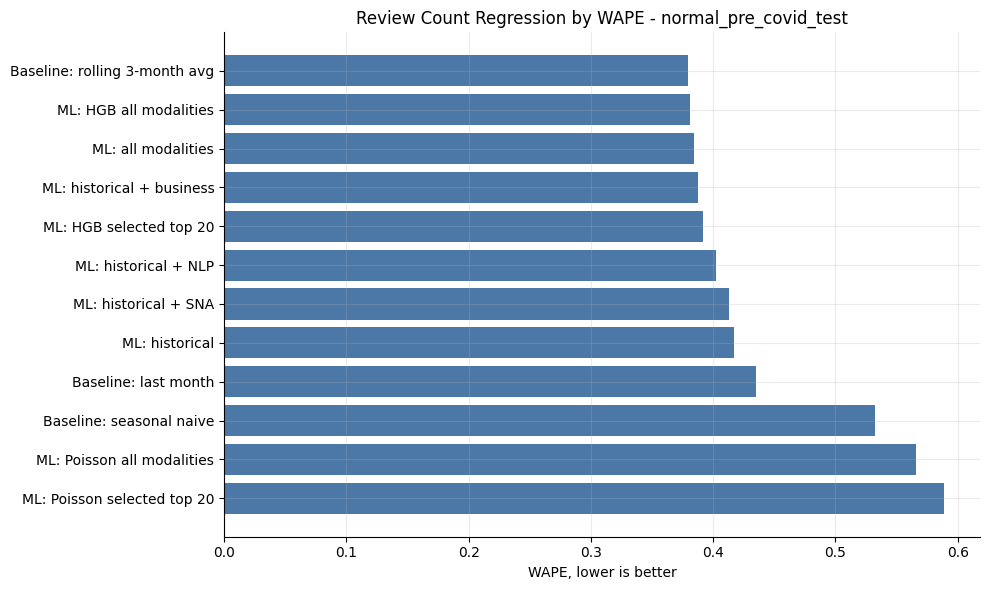

outputs\figures\models\review_count_wape_comparison_normal_pre_covid_test.png


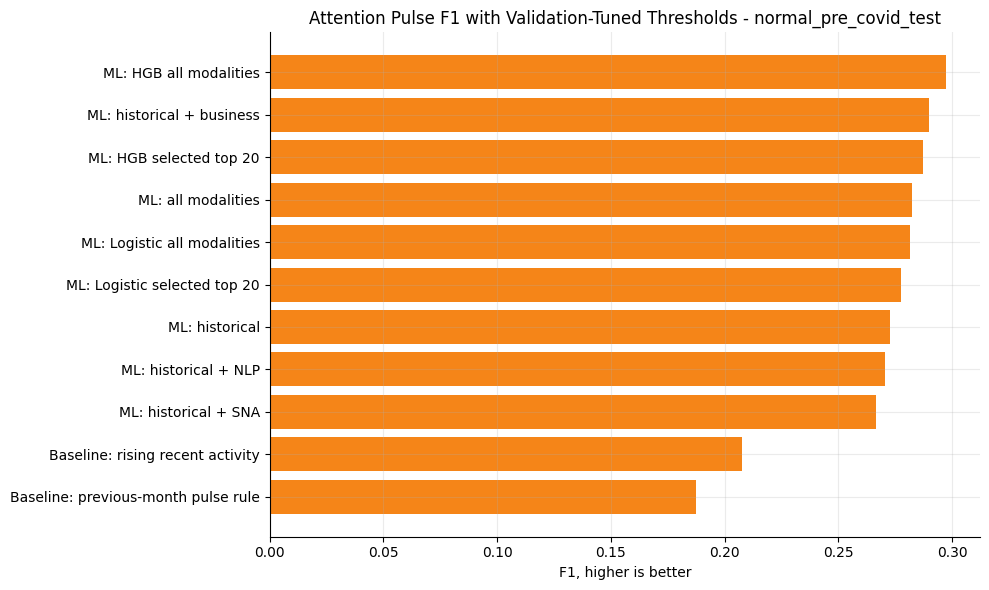

outputs\figures\models\attention_pulse_f1_comparison_normal_pre_covid_test.png


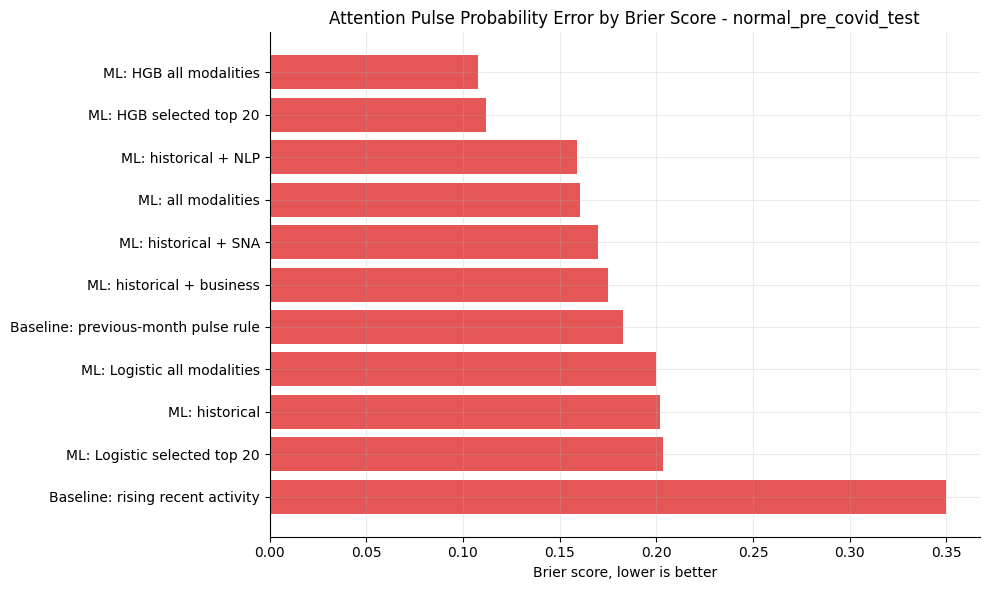

outputs\figures\models\attention_pulse_brier_comparison_normal_pre_covid_test.png


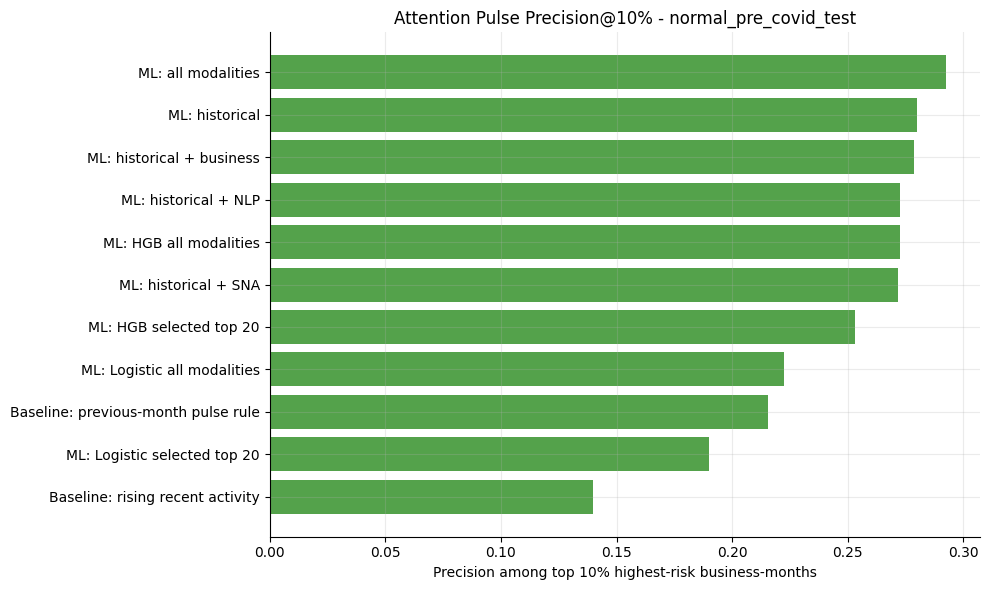

outputs\figures\models\attention_pulse_precision_at_10pct_normal_pre_covid_test.png


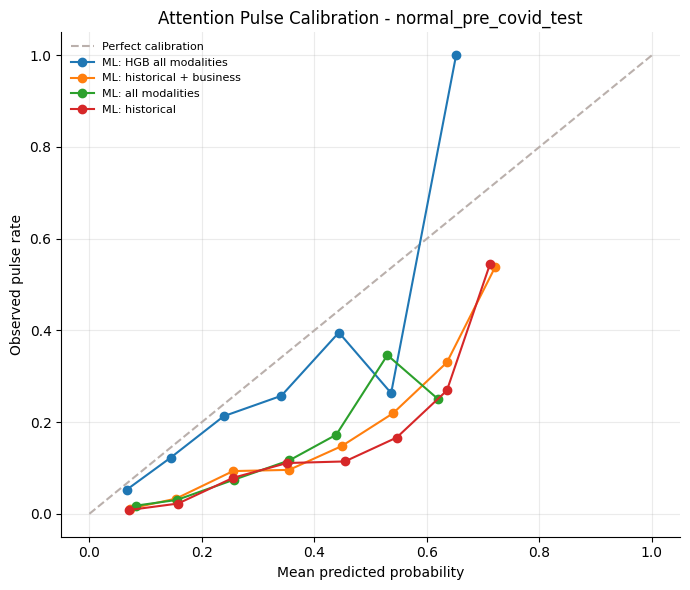

outputs\figures\models\attention_pulse_calibration_normal_pre_covid_test.png


In [5]:
# Regression WAPE figures
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Review Count Regression by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()

    path = FIGURES_DIR / f"review_count_wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))


# Pulse F1 figures
for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("F1", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["F1"], color="#F58518")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse F1 with Validation-Tuned Thresholds - {split_name}")
    ax.set_xlabel("F1, higher is better")
    fig.tight_layout()

    path = FIGURES_DIR / f"attention_pulse_f1_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))


# Pulse Brier figures
for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("Brier")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["Brier"], color="#E45756")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Probability Error by Brier Score - {split_name}")
    ax.set_xlabel("Brier score, lower is better")
    fig.tight_layout()

    path = FIGURES_DIR / f"attention_pulse_brier_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))


# Precision@10 figures
for split_name in pulse_topk_metrics_df["split"].unique():
    split_topk = pulse_topk_metrics_df[
        (pulse_topk_metrics_df["split"] == split_name)
        & (pulse_topk_metrics_df["k_fraction"] == 0.10)
    ].sort_values("precision_at_k", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_topk["model"], split_topk["precision_at_k"], color="#54A24B")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Precision@10% - {split_name}")
    ax.set_xlabel("Precision among top 10% highest-risk business-months")
    fig.tight_layout()

    path = FIGURES_DIR / f"attention_pulse_precision_at_10pct_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))


# Calibration figures
for split_name in pulse_calibration_df["split"].unique():
    best_models = (
        pulse_metrics_df[pulse_metrics_df["split"] == split_name]
        .sort_values(["PR_AUC", "Brier"], ascending=[False, True])
        .head(4)["model"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], color="#BAB0AC", linestyle="--", label="Perfect calibration")

    for model_name in best_models:
        line_df = pulse_calibration_df[
            (pulse_calibration_df["split"] == split_name)
            & (pulse_calibration_df["model"] == model_name)
        ]
        ax.plot(
            line_df["mean_predicted_probability"],
            line_df["observed_pulse_rate"],
            marker="o",
            label=model_name,
        )

    ax.set_title(f"Attention Pulse Calibration - {split_name}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed pulse rate")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()

    path = FIGURES_DIR / f"attention_pulse_calibration_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))

The best performance comes from the rolling 3-month average baseline, with HGB/all-modality ML models very close behind. This suggests pre-COVID review counts are largely driven by recent activity, while added business, NLP, and SNA features give only limited improvement. Poisson models perform worst, indicating they are less suited to this skewed, volatile target.

For attention-pulse detection, ML models clearly outperform simple baselines. The best F1 scores come from HGB with all modalities and historical + business features, showing that pulse events require richer signals than recent activity alone. However, overall F1 remains modest, reflecting the rarity and difficulty of predicting pulses.

For pulse probabilities, HGB models are best calibrated, with the all-modality HGB model achieving the lowest Brier score. This adds that richer features improve not just pulse classification, but also probability quality. Logistic and simple baseline approaches are less reliable for estimating pulse risk.

At the top 10% highest-risk cases, historical + business features give the best precision, narrowly ahead of all modalities. This suggests business-level context is especially useful for ranking likely pulse events, while adding every feature type does not always improve prioritization.

The calibration plot shows that most models overestimate pulse risk, since observed pulse rates often fall below predicted probabilities. HGB models are closest to the ideal line in the mid-risk range, while the all-modality model becomes less reliable at higher predicted probabilities. This supports using HGB probabilities carefully, especially for high-risk cases.

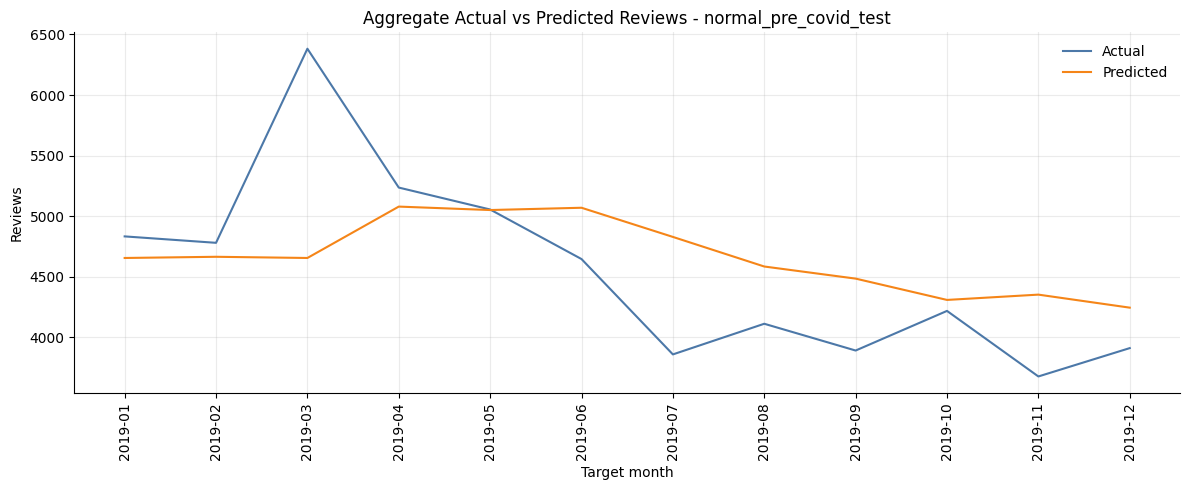

outputs\figures\models\review_count_actual_vs_predicted_normal_pre_covid_test.png


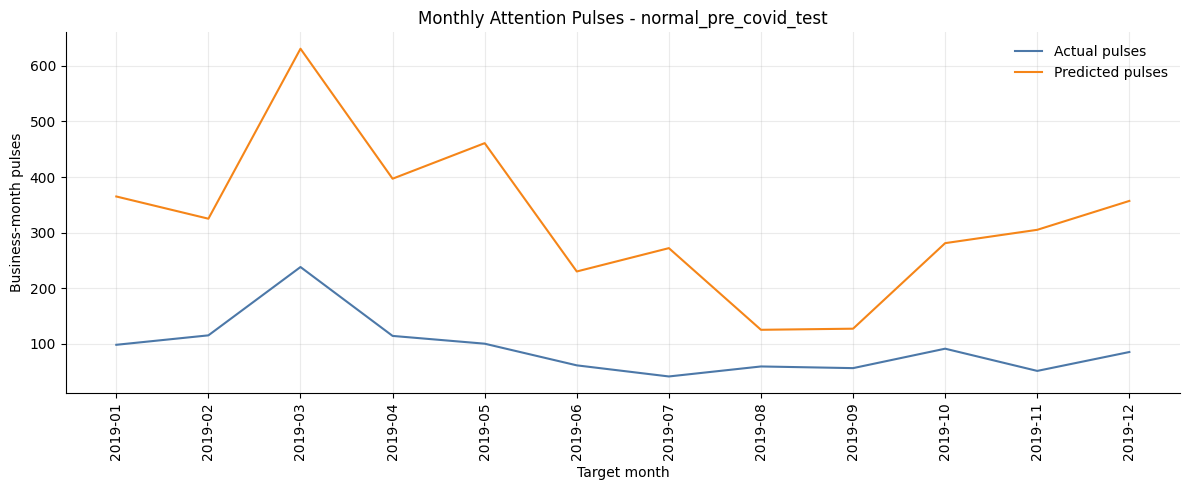

outputs\figures\models\attention_pulse_actual_vs_predicted_normal_pre_covid_test.png


In [6]:
# Select comparison model
comparison_model = "ML: HGB selected top 20"
fallback_model = "ML: all modalities"

if comparison_model not in set(predictions_df["model"]):
    comparison_model = fallback_model

# Review count actual vs predicted
for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[
        (predictions_df["split"] == split_name)
        & (predictions_df["model"] == comparison_model)
    ].copy()

    monthly = (
        plot_df
        .groupby("target_month_str")
        .agg(
            actual=("target_next_month_reviews", "sum"),
            predicted=("prediction", "sum"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = FIGURES_DIR / f"review_count_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))


# Pulse actual vs predicted
for split_name in pulse_predictions_df["split"].unique():
    plot_df = pulse_predictions_df[
        (pulse_predictions_df["split"] == split_name)
        & (pulse_predictions_df["model"] == comparison_model)
    ].copy()

    monthly = (
        plot_df
        .groupby("target_month_str")
        .agg(
            actual_pulses=("attention_pulse", "sum"),
            predicted_pulses=("prediction", "sum"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual_pulses"], label="Actual pulses", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted_pulses"], label="Predicted pulses", color="#F58518")
    ax.set_title(f"Monthly Attention Pulses - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Business-month pulses")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = FIGURES_DIR / f"attention_pulse_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))

The review-count model captures the general 2019 decline but smooths over sharp month-to-month changes, especially the March spike. For attention pulses, predictions are consistently much higher than actual counts, confirming poor calibration at the aggregate level. This means the model is better for broad ranking than for estimating the true number of pulse events.

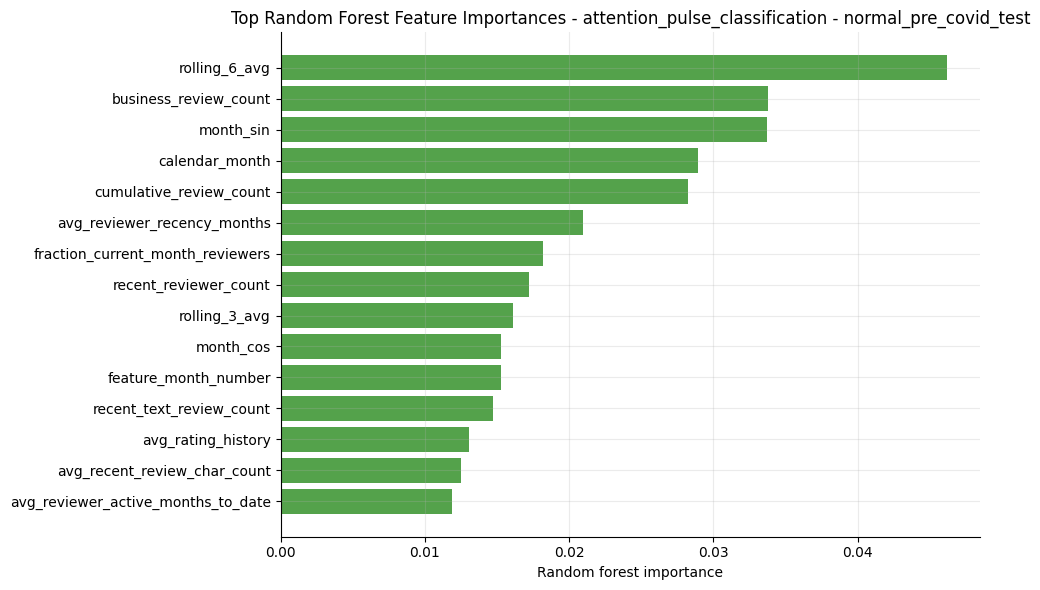

outputs\figures\models\attention_pulse_feature_importance_normal_pre_covid_test.png


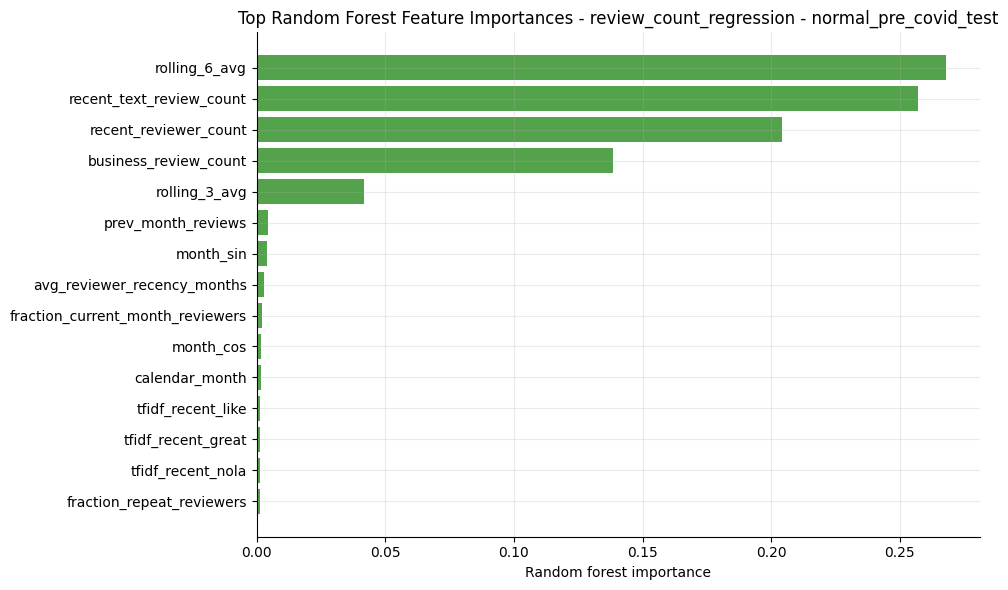

outputs\figures\models\review_count_feature_importance_normal_pre_covid_test.png


,task,split,feature,importance
102,attention_pulse_classification,normal_pre_covid_test,rolling_6_avg,0.046184
111,attention_pulse_classification,normal_pre_covid_test,business_review_count,0.033822
107,attention_pulse_classification,normal_pre_covid_test,month_sin,0.033692
106,attention_pulse_classification,normal_pre_covid_test,calendar_month,0.028926
104,attention_pulse_classification,normal_pre_covid_test,cumulative_review_count,0.028269
137,attention_pulse_classification,normal_pre_covid_test,avg_reviewer_recency_months,0.020946
138,attention_pulse_classification,normal_pre_covid_test,fraction_current_month_reviewers,0.018208
116,attention_pulse_classification,normal_pre_covid_test,recent_reviewer_count,0.017200
101,attention_pulse_classification,normal_pre_covid_test,rolling_3_avg,0.016096
108,attention_pulse_classification,normal_pre_covid_test,month_cos,0.015269


In [7]:
# Feature importances
importance_rows = []

for (split_name, model_name), (model, features, family) in regression_models.items():
    if model_name != "ML: all modalities" or not hasattr(model, "feature_importances_"):
        continue

    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({
            "task": "review_count_regression",
            "split": split_name,
            "feature": feature,
            "importance": importance,
        })

for (split_name, model_name), (model, features, family, decision_threshold) in pulse_models.items():
    if model_name != "ML: all modalities" or not hasattr(model, "feature_importances_"):
        continue

    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({
            "task": "attention_pulse_classification",
            "split": split_name,
            "feature": feature,
            "importance": importance,
        })

importance_df = pd.DataFrame(importance_rows).sort_values(
    ["task", "split", "importance"],
    ascending=[True, True, False],
)

# Plot importances
for (task, split_name), group in importance_df.groupby(["task", "split"]):
    top_importance = group.head(15).sort_values("importance")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Random Forest Feature Importances - {task} - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()

    safe_task = task.replace("_classification", "").replace("_regression", "")
    path = FIGURES_DIR / f"{safe_task}_feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)

    print(path.relative_to(PROJECT_ROOT))

importance_df.head(20)

Feature importance reinforces that recent demand dominates both tasks. Review-count regression relies especially on rolling averages, recent text-review volume, and recent reviewer counts, while pulse classification uses a broader mix including seasonality, business popularity, reviewer recency, and current-month reviewer share. This suggests pulses are less about volume alone and more about changes in engagement context.

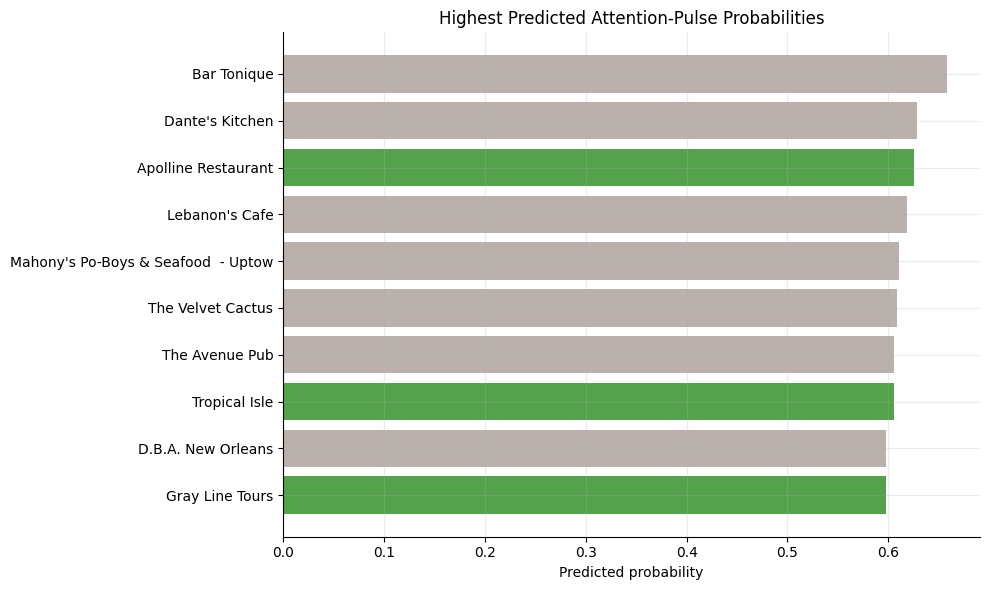

outputs\figures\models\attention_pulse_top_predicted_examples.png


,business_id,name,target_month_str,attention_pulse,target_next_month_reviews,pulse_baseline_reviews,pulse_relative_lift,probability
0,wQNkpi9RvpuoiDB-CiHxog,Bar Tonique,2019-03,0,4.0,3.833333,1.043478,0.657941
1,yf8a1DOlqoqlKHuLSKEfxg,Dante's Kitchen,2019-04,0,0.0,0.166667,0.000000,0.628045
2,mBXxL7776PIpye9GRDLu6Q,Apolline Restaurant,2019-03,1,7.0,3.166667,2.210526,0.625282
3,aeIWVa6G54UUo6yloJkyJg,Lebanon's Cafe,2019-03,0,3.0,3.500000,0.857143,0.618625
4,stqWlKEgXweNQSsxOsHjVA,Mahony's Po-Boys & Seafood - Uptown,2019-03,0,3.0,5.333333,0.562500,0.610375
5,iQp3QlP4iynGTXgFqpZ7Gg,The Velvet Cactus,2019-03,0,4.0,4.000000,1.000000,0.608759
6,JhpRI9m71ybWHkAqRdL0Tg,The Avenue Pub,2019-03,0,4.0,2.500000,1.600000,0.605653
7,UH87t9fT_oTLMZfr5iCbQg,Tropical Isle,2019-03,1,12.0,3.000000,4.000000,0.605471
8,7kHvPCBSmRgzDgjO9xXT1g,D.B.A. New Orleans,2019-03,0,3.0,1.833333,1.636364,0.597836
9,vAtVp9NI8uyqDM7Wi7pcVA,Gray Line Tours,2019-03,1,8.0,4.000000,2.000000,0.597673


In [8]:
# Top pulse examples
example_split = "normal_pre_covid_test"
example_model = "ML: all modalities"

examples = (
    pulse_predictions_df[
        (pulse_predictions_df["split"] == example_split)
        & (pulse_predictions_df["model"] == example_model)
    ]
    .sort_values("probability", ascending=False)
    .head(10)
    .merge(business_lookup, on="business_id", how="left")
)

# Plot examples
fig, ax = plt.subplots(figsize=(10, 6))
labels = examples["name"].fillna(examples["business_id"]).str.slice(0, 35)
colors = np.where(examples["attention_pulse"].eq(1), "#54A24B", "#BAB0AC")

ax.barh(labels[::-1], examples["probability"].values[::-1], color=colors[::-1])
ax.set_title("Highest Predicted Attention-Pulse Probabilities")
ax.set_xlabel("Predicted probability")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "attention_pulse_top_predicted_examples.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

print(path.relative_to(PROJECT_ROOT))

examples[[
    "business_id",
    "name",
    "target_month_str",
    "attention_pulse",
    "target_next_month_reviews",
    "pulse_baseline_reviews",
    "pulse_relative_lift",
    "probability",
]]

## Prophet Benchmark for Top Businesses

Here let's fit a business-level Prophet model for each of the top 10 businesses by total monthly review count. This benchmark uses only each business's own monthly review history, with yearly seasonality enabled and weekly/daily seasonality disabled. The train period is 2015-2017 and the held-out normal-period test year is 2019.

In [10]:
# Imports
import logging

# Load Prophet
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from prophet import Prophet
except ImportError as exc:
    raise ImportError("Install Prophet with `pip install prophet` before running this section.") from exc

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Prophet windows
PROPHET_TRAIN_START = pd.Timestamp("2015-01-01")
PROPHET_TRAIN_END = pd.Timestamp("2017-12-01")
PROPHET_TEST_START = pd.Timestamp("2019-01-01")
PROPHET_TEST_END = pd.Timestamp("2019-12-01")

# Select monthly columns
if {"year_month", "review_count"}.issubset(modeling.columns):
    month_column = "year_month"
    count_column = "review_count"
elif {"target_month_str", "target_next_month_reviews"}.issubset(modeling.columns):
    month_column = "target_month_str"
    count_column = "target_next_month_reviews"
elif {"feature_month_str", "monthly_review_count"}.issubset(modeling.columns):
    month_column = "feature_month_str"
    count_column = "monthly_review_count"
else:
    raise ValueError("Prophet section needs year_month/review_count or the notebook's monthly target columns.")

# Monthly Prophet series
prophet_series = (
    modeling[["business_id", month_column, count_column]]
    .rename(columns={month_column: "ds", count_column: "y"})
    .assign(
        ds=lambda df: pd.to_datetime(df["ds"]).dt.to_period("M").dt.to_timestamp(),
        y=lambda df: df["y"].astype(float),
    )
    .groupby(["business_id", "ds"], as_index=False)["y"]
    .sum()
)

prophet_series = prophet_series[
    (prophet_series["ds"] >= PROPHET_TRAIN_START)
    & (prophet_series["ds"] <= PROPHET_TEST_END)
]

# Top businesses
top10_business_ids = (
    prophet_series.groupby("business_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

business_names = (
    business_lookup
    .drop_duplicates("business_id")
    .set_index("business_id")["name"]
    .to_dict()
)

# Prophet containers
prophet_models = {}
prophet_forecasts = {}
prophet_prediction_frames = []
prophet_business_metrics = []
skipped_prophet_businesses = []

# Fit Prophet models
for business_id in top10_business_ids:
    business_series = prophet_series[prophet_series["business_id"] == business_id].sort_values("ds")

    train_series = business_series[
        (business_series["ds"] >= PROPHET_TRAIN_START)
        & (business_series["ds"] <= PROPHET_TRAIN_END)
    ][["ds", "y"]]

    test_series = business_series[
        (business_series["ds"] >= PROPHET_TEST_START)
        & (business_series["ds"] <= PROPHET_TEST_END)
    ][["ds", "y"]]

    if len(train_series) < 24 or test_series.empty:
        skipped_prophet_businesses.append(business_id)
        continue

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    model.fit(train_series)

    future = pd.DataFrame({
        "ds": pd.date_range(train_series["ds"].min(), PROPHET_TEST_END, freq="MS")
    })

    forecast = model.predict(future)
    forecast_columns = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "yearly"]

    business_predictions = test_series.merge(forecast[forecast_columns], on="ds", how="left")
    business_predictions["yhat"] = np.clip(business_predictions["yhat"], 0, None)
    business_predictions = business_predictions.assign(
        business_id=business_id,
        name=business_names.get(business_id, business_id),
        model="Prophet",
    )

    prophet_models[business_id] = model
    prophet_forecasts[business_id] = forecast
    prophet_prediction_frames.append(business_predictions)

    prophet_business_metrics.append({
        "business_id": business_id,
        "name": business_names.get(business_id, business_id),
        "train_months": len(train_series),
        "test_months": len(test_series),
        "MAE": mean_absolute_error(business_predictions["y"], business_predictions["yhat"]),
        "RMSE": mean_squared_error(business_predictions["y"], business_predictions["yhat"]) ** 0.5,
    })

# Skipped businesses
if skipped_prophet_businesses:
    print(f"Skipped Prophet fits for insufficient coverage: {skipped_prophet_businesses}")

# Prophet outputs
prophet_predictions = pd.concat(prophet_prediction_frames, ignore_index=True)
prophet_summary = pd.DataFrame(prophet_business_metrics).sort_values("RMSE").reset_index(drop=True)

prophet_summary

22:24:29 - cmdstanpy - INFO - Chain [1] start processing
22:24:31 - cmdstanpy - INFO - Chain [1] done processing
22:24:31 - cmdstanpy - INFO - Chain [1] start processing
22:24:32 - cmdstanpy - INFO - Chain [1] done processing
22:24:32 - cmdstanpy - INFO - Chain [1] start processing
22:24:32 - cmdstanpy - INFO - Chain [1] done processing
22:24:33 - cmdstanpy - INFO - Chain [1] start processing
22:24:33 - cmdstanpy - INFO - Chain [1] done processing
22:24:34 - cmdstanpy - INFO - Chain [1] start processing
22:24:35 - cmdstanpy - INFO - Chain [1] done processing
22:24:35 - cmdstanpy - INFO - Chain [1] start processing
22:24:35 - cmdstanpy - INFO - Chain [1] done processing
22:24:36 - cmdstanpy - INFO - Chain [1] start processing
22:24:37 - cmdstanpy - INFO - Chain [1] done processing
22:24:37 - cmdstanpy - INFO - Chain [1] start processing
22:24:38 - cmdstanpy - INFO - Chain [1] done processing
22:24:38 - cmdstanpy - INFO - Chain [1] start processing
22:24:39 - cmdstanpy - INFO - Chain [1]

,business_id,name,train_months,test_months,MAE,RMSE
0,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,35,12,8.323513,9.825147
1,_C7QiQQc47AOEv4PE3Kong,Commander's Palace,35,12,8.653365,10.227640
2,iSRTaT9WngzB8JJ2YKJUig,Mother's Restaurant,35,12,7.783975,10.330692
3,oBNrLz4EDhiscSlbOl8uAw,Ruby Slipper - New Orleans,35,12,12.923479,15.223642
4,qb28j-FNX1_6xm7u372TZA,Gumbo Shop,35,12,13.806975,15.495538
5,6a4gLLFSgr-Q6CZXDLzBGQ,Cochon,35,12,12.599261,15.909711
6,VaO-VW3e1kARkU9bP1E7Fw,Felix's Restaurant & Oyster Bar,35,12,13.350531,16.190440
7,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,35,12,17.469261,20.718430
8,VQcCL9PiNL_wkGf-uF3fjg,Royal House,35,12,17.872785,21.334268
9,ac1AeYqs8Z4_e2X5M3if2A,Oceana Grill,35,12,30.925833,34.453361


In [11]:
# Prophet aggregate metrics
prophet_actual = prophet_predictions["y"].astype(float)
prophet_pred = prophet_predictions["yhat"].astype(float)

prophet_aggregate_row = {
    "split": "normal_pre_covid_test",
    "task": "review_count_regression_top10",
    "model": "Prophet",
    "model_name": "Prophet",
    "train_period": "2015-01 to 2017-12",
    "validation_period": "not used",
    "test_period": "2019-01 to 2019-12",
    "rows": len(prophet_predictions),
    "MAE": mean_absolute_error(prophet_actual, prophet_pred),
    "RMSE": mean_squared_error(prophet_actual, prophet_pred) ** 0.5,
    "WAPE": wape(prophet_actual.values, prophet_pred.values),
    "model_family": "Prophet",
    "feature_count": 0,
    "business_count": prophet_predictions["business_id"].nunique(),
    "scope": "top_10_businesses_by_total_reviews",
}

# Load existing metrics
existing_metrics = pd.read_csv(METRICS_OUTPUT_PATH) if METRICS_OUTPUT_PATH.exists() else metrics_df.copy()

if "model_name" not in existing_metrics.columns:
    existing_metrics["model_name"] = existing_metrics["model"] if "model" in existing_metrics.columns else np.nan

for column in prophet_aggregate_row:
    if column not in existing_metrics.columns:
        existing_metrics[column] = np.nan

# Align Prophet row
prophet_row_df = pd.DataFrame([prophet_aggregate_row])

for column in existing_metrics.columns:
    if column not in prophet_row_df.columns:
        prophet_row_df[column] = np.nan

prophet_row_df = prophet_row_df[existing_metrics.columns]

# Replace old Prophet row
metric_model = existing_metrics["model"].astype(str) if "model" in existing_metrics.columns else pd.Series("", index=existing_metrics.index)
metric_model_name = existing_metrics["model_name"].astype(str) if "model_name" in existing_metrics.columns else pd.Series("", index=existing_metrics.index)

prophet_metric_mask = (
    ((metric_model == "Prophet") | (metric_model_name == "Prophet"))
    & (existing_metrics["split"] == "normal_pre_covid_test")
    & (existing_metrics["task"] == "review_count_regression_top10")
)

updated_metrics = pd.concat([existing_metrics.loc[~prophet_metric_mask], prophet_row_df], ignore_index=True)
updated_metrics.to_csv(METRICS_OUTPUT_PATH, index=False)

# Save Prophet outputs
prophet_summary.to_csv(OUTPUTS_DIR / "prophet_top10_business_metrics.csv", index=False)
prophet_predictions.to_csv(OUTPUTS_DIR / "prophet_top10_predictions.csv", index=False)

# ML comparison set
top10_id_set = set(top10_business_ids)
top10_ml_predictions = predictions_df[
    (predictions_df["split"] == "normal_pre_covid_test")
    & (predictions_df["business_id"].isin(top10_id_set))
].copy()

# Compare Prophet and ML
comparison_rows = [{
    "model": "Prophet",
    "scope": "top-10 businesses",
    "rows": len(prophet_predictions),
    "MAE": prophet_aggregate_row["MAE"],
    "RMSE": prophet_aggregate_row["RMSE"],
    "WAPE": prophet_aggregate_row["WAPE"],
}]

for model_name, group in top10_ml_predictions.groupby("model"):
    y_true = group["target_next_month_reviews"].astype(float).values
    y_pred = np.clip(group["prediction"].astype(float).values, 0, None)

    comparison_rows.append({
        "model": model_name,
        "scope": "same top-10 businesses",
        "rows": len(group),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    })

# Save comparison
prophet_ml_comparison = pd.DataFrame(comparison_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
prophet_ml_comparison.to_csv(OUTPUTS_DIR / "prophet_top10_ml_comparison.csv", index=False)

prophet_ml_comparison

,model,scope,rows,MAE,RMSE,WAPE
0,Baseline: rolling 3-month avg,same top-10 businesses,120,10.138889,12.988171,0.162287
1,Baseline: last month,same top-10 businesses,120,12.116667,15.188263,0.193944
2,Prophet,top-10 businesses,120,14.370898,18.347806,0.230026
3,ML: HGB selected top 20,same top-10 businesses,120,13.964939,21.236466,0.223528
4,Baseline: seasonal naive,same top-10 businesses,120,16.883333,21.427786,0.270241
5,ML: HGB all modalities,same top-10 businesses,120,14.192681,21.480684,0.227174
6,ML: historical + SNA,same top-10 businesses,120,14.106620,21.880916,0.225796
7,ML: historical + NLP,same top-10 businesses,120,13.982239,22.173901,0.223805
8,ML: historical,same top-10 businesses,120,14.345039,22.372147,0.229612
9,ML: all modalities,same top-10 businesses,120,14.429622,22.473219,0.230966


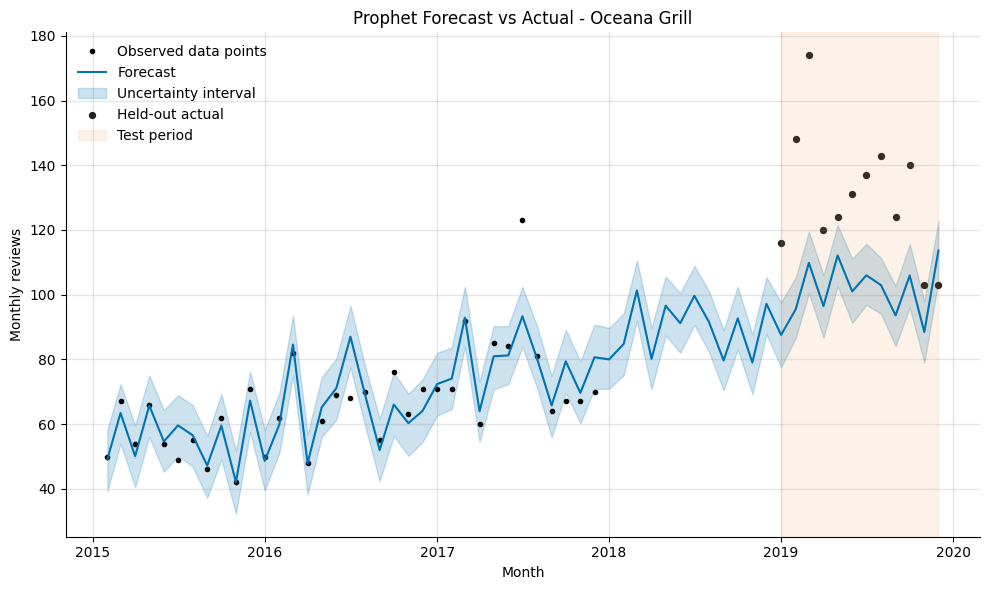

outputs\figures\models\prophet_forecast_ac1AeYqs8Z4_e2X5M3if2A.png


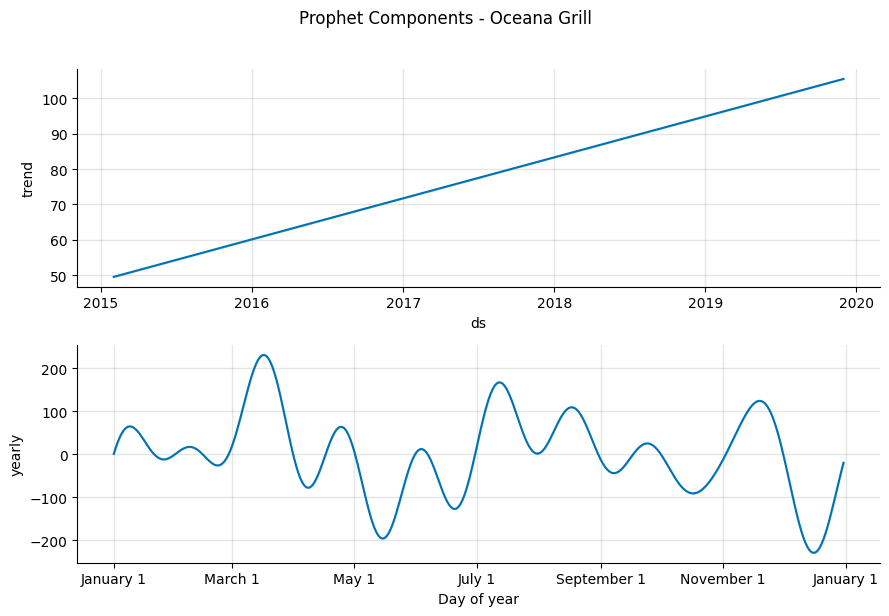

outputs\figures\models\prophet_components_ac1AeYqs8Z4_e2X5M3if2A.png


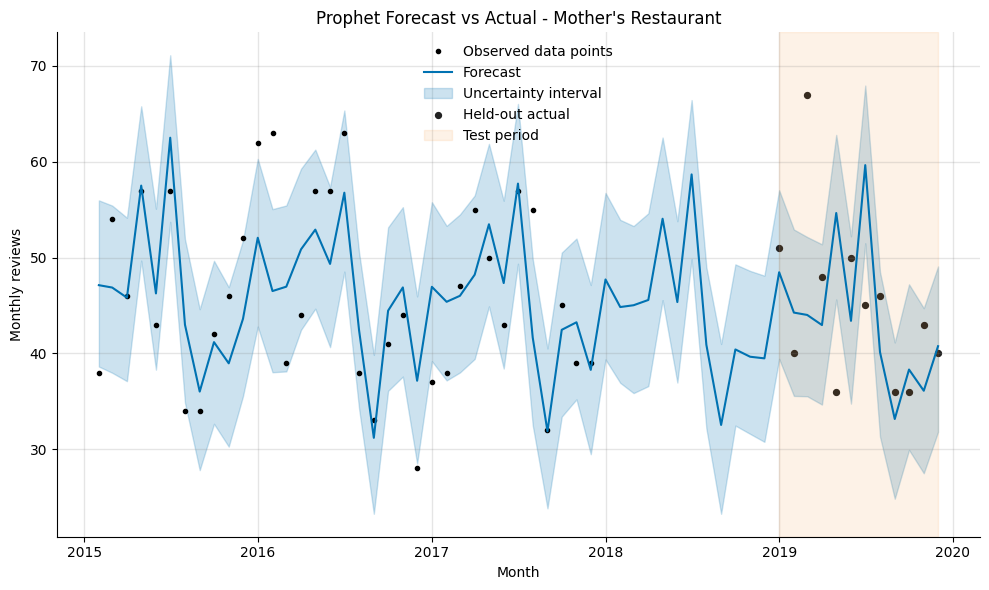

outputs\figures\models\prophet_forecast_iSRTaT9WngzB8JJ2YKJUig.png


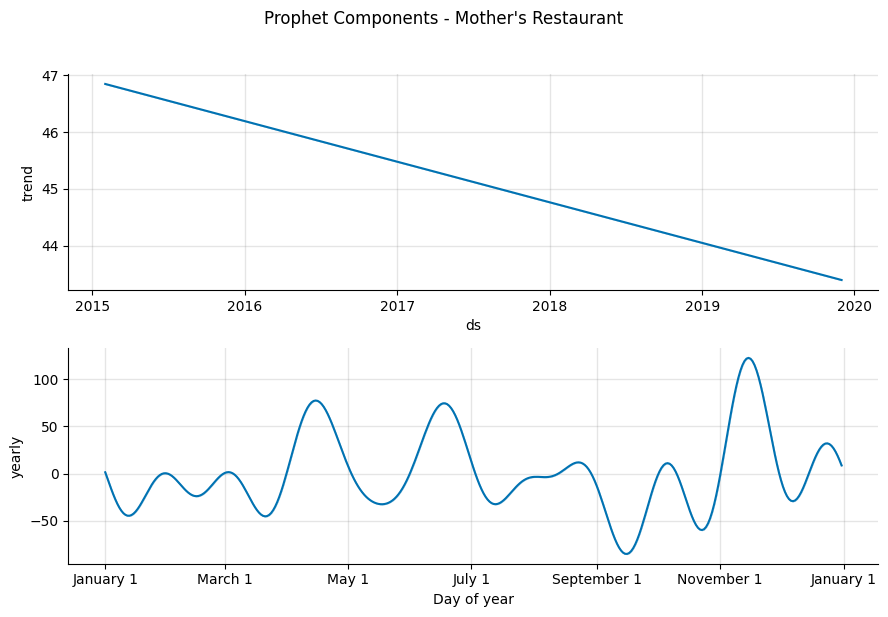

outputs\figures\models\prophet_components_iSRTaT9WngzB8JJ2YKJUig.png


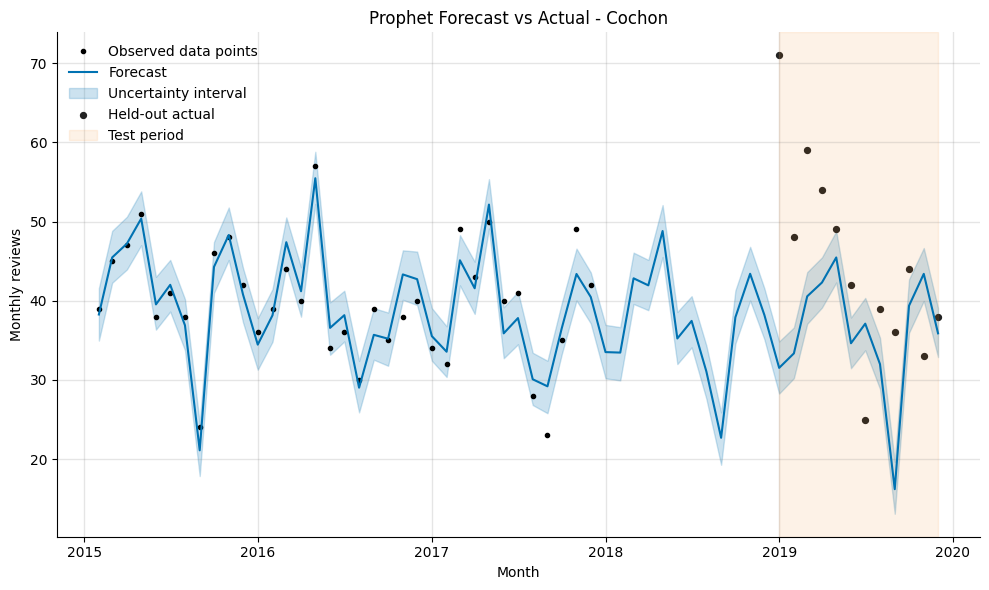

outputs\figures\models\prophet_forecast_6a4gLLFSgr_Q6CZXDLzBGQ.png


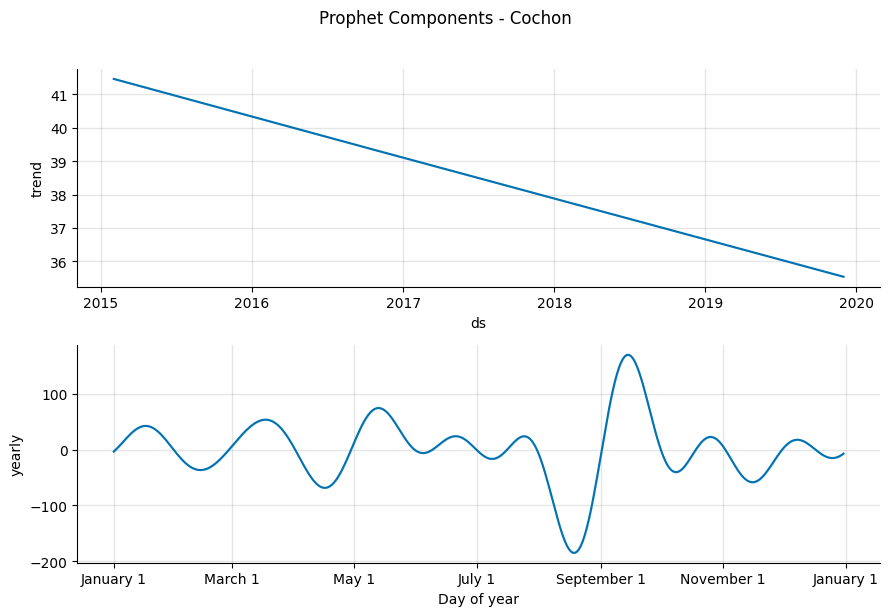

outputs\figures\models\prophet_components_6a4gLLFSgr_Q6CZXDLzBGQ.png


In [12]:
# Representative businesses
representative_positions = [0, len(top10_business_ids) // 2, len(top10_business_ids) - 1]
representative_business_ids = []

for position in representative_positions:
    candidate = top10_business_ids[position]

    if candidate in prophet_models and candidate not in representative_business_ids:
        representative_business_ids.append(candidate)


# Plot Prophet outputs
for business_id in representative_business_ids:
    model = prophet_models[business_id]
    forecast = prophet_forecasts[business_id]
    name = business_names.get(business_id, business_id)
    safe_business_id = "".join(character if character.isalnum() else "_" for character in business_id)

    business_actual = prophet_series[prophet_series["business_id"] == business_id]
    test_actual = business_actual[
        (business_actual["ds"] >= PROPHET_TEST_START)
        & (business_actual["ds"] <= PROPHET_TEST_END)
    ]

    # Forecast plot
    fig = model.plot(forecast, xlabel="Month", ylabel="Monthly reviews")
    ax = fig.axes[0]
    ax.scatter(test_actual["ds"], test_actual["y"], color="#222222", s=18, label="Held-out actual")
    ax.axvspan(PROPHET_TEST_START, PROPHET_TEST_END, color="#F58518", alpha=0.10, label="Test period")
    ax.set_title(f"Prophet Forecast vs Actual - {name}")
    ax.legend(frameon=False)
    fig.tight_layout()

    forecast_path = FIGURES_DIR / f"prophet_forecast_{safe_business_id}.png"
    fig.savefig(forecast_path, dpi=160)
    plt.show()
    plt.close(fig)

    print(forecast_path.relative_to(PROJECT_ROOT))

    # Component plot
    component_fig = model.plot_components(forecast)
    component_fig.suptitle(f"Prophet Components - {name}", y=1.02)
    component_fig.tight_layout()

    components_path = FIGURES_DIR / f"prophet_components_{safe_business_id}.png"
    component_fig.savefig(components_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(component_fig)

    print(components_path.relative_to(PROJECT_ROOT))

## Community-Level Prophet Forecasts

Let's evaluate whether the five largest reviewer communities have forecastable aggregate review rhythms. We will use the same Prophet configuration as the business-level benchmark (`yearly_seasonality=True`, `weekly_seasonality=False`, `daily_seasonality=False`) and reuse the same train/test dates, so the community MAE is read against the same normal pre-COVID holdout period.

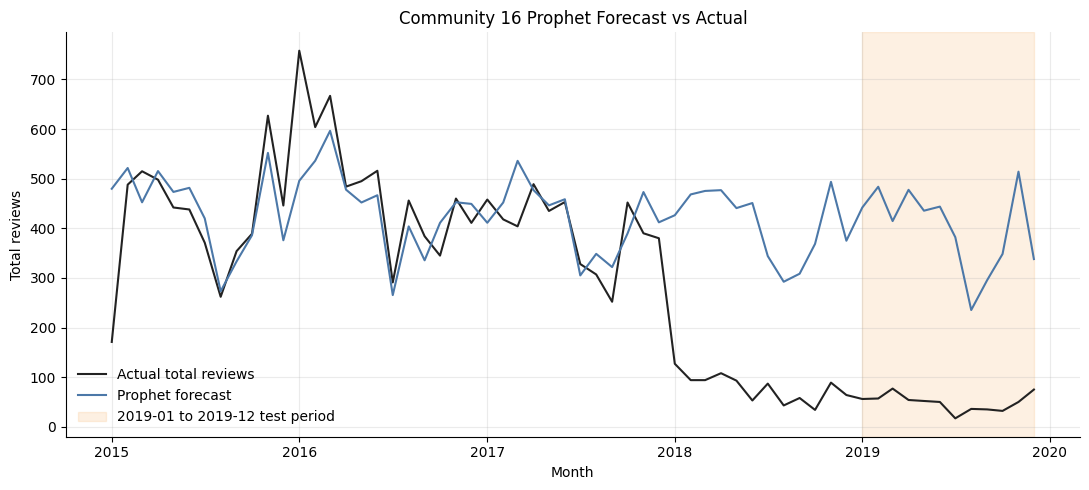

outputs\figures\models\community_forecast_16.png


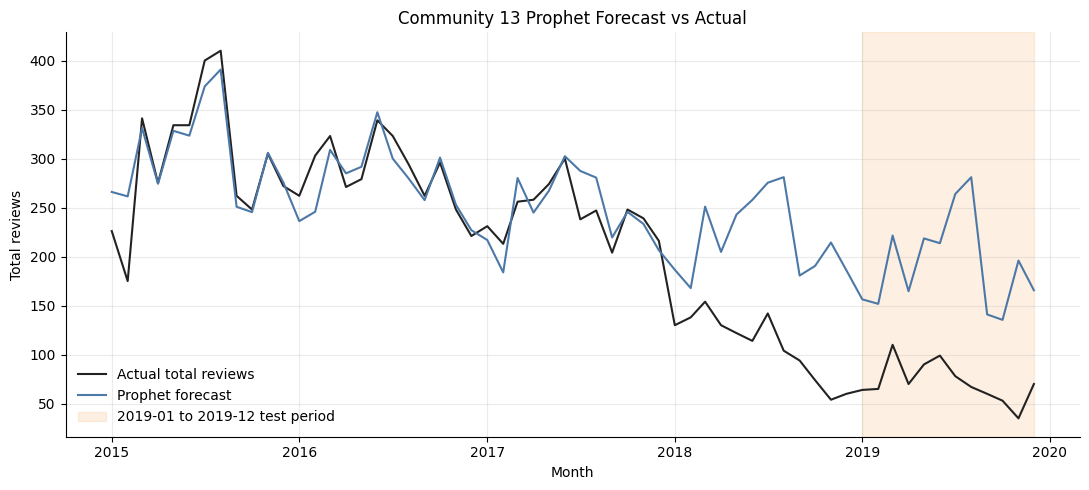

outputs\figures\models\community_forecast_13.png


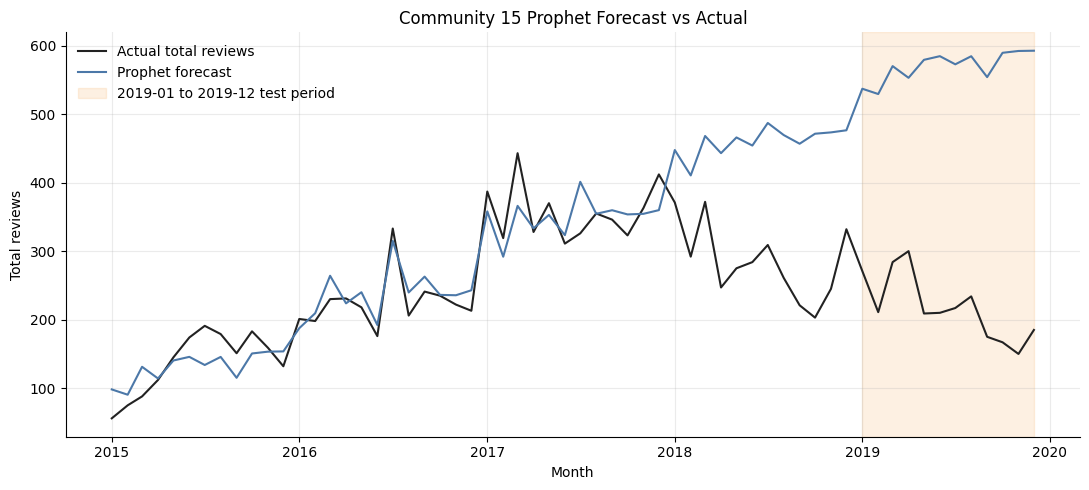

outputs\figures\models\community_forecast_15.png


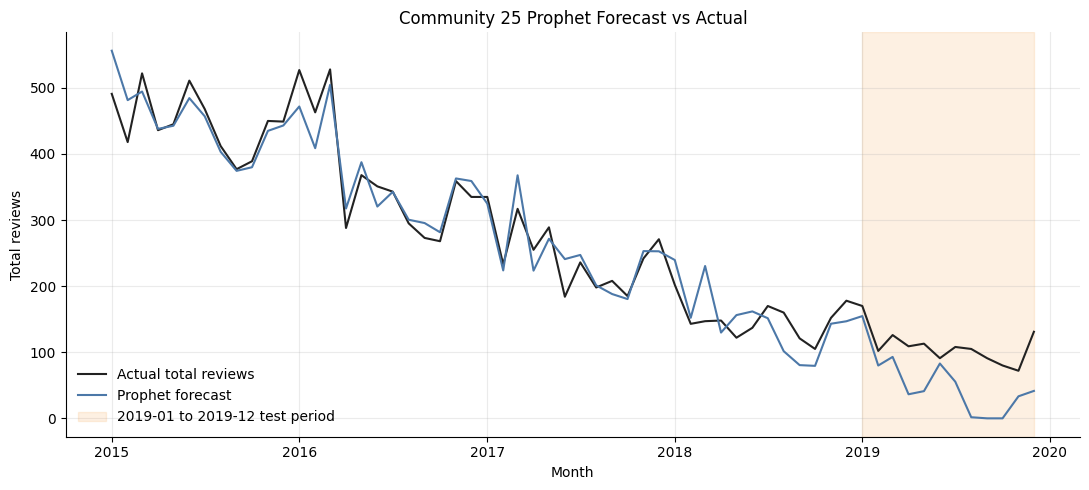

outputs\figures\models\community_forecast_25.png


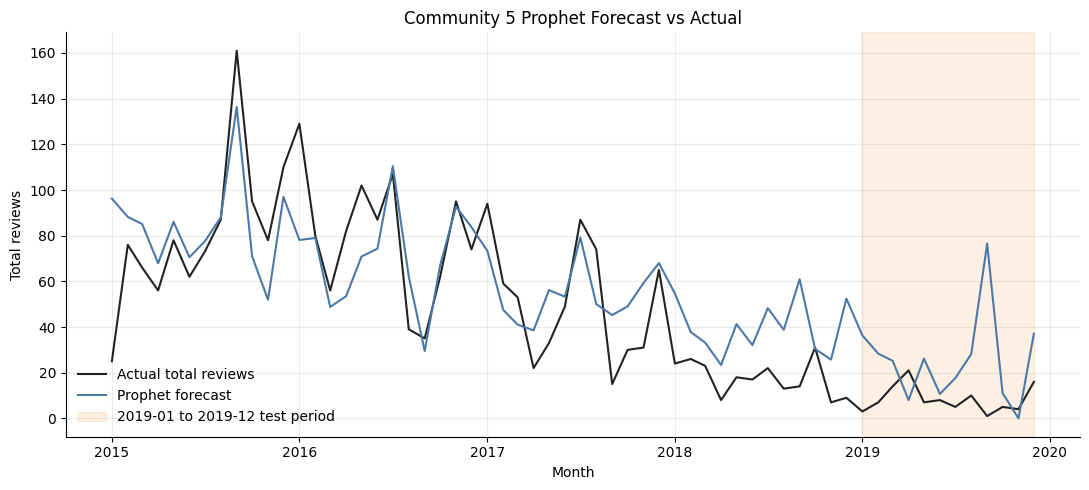

outputs\figures\models\community_forecast_5.png


,community_id,community_size,train_months,test_months,test_total_reviews,MAE,RMSE,WAPE
0,5,263,36,12,101.0,19.852137,27.275856,2.358670
1,25,490,36,12,1298.0,56.495095,64.507153,0.522297
2,13,828,36,12,861.0,120.694463,127.753898,1.682153
3,16,1678,36,12,591.0,351.653593,359.672029,7.140174
4,15,514,36,12,2613.0,352.129504,356.882946,1.617127


In [13]:
# Fit a Prophet model per top reviewer community and report MAE on the same holdout as the business Prophet benchmark.
import logging

IN_NOTEBOOK = "get_ipython" in globals()
if not IN_NOTEBOOK:
    plt.switch_backend("Agg")

try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from prophet import Prophet
except ImportError as exc:
    raise ImportError("Install Prophet with `pip install prophet` before running this section.") from exc

for logger_name in ["cmdstanpy", "prophet"]:
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.ERROR)
    logger.disabled = True

COMMUNITY_MONTH_SERIES_PATH = PROCESSED_DIR / "community_month_series.csv"
COMMUNITY_PROPHET_METRICS_PATH = OUTPUTS_DIR / "community_prophet_metrics.csv"
COMMUNITY_PROPHET_PREDICTIONS_PATH = OUTPUTS_DIR / "community_prophet_predictions.csv"
for stale_community_forecast in FIGURES_DIR.glob("community_forecast_*.png"):
    stale_community_forecast.unlink()
COMMUNITY_PROPHET_TRAIN_START = PROPHET_TRAIN_START if "PROPHET_TRAIN_START" in globals() else pd.Timestamp("2015-01-01")
COMMUNITY_PROPHET_TRAIN_END = PROPHET_TRAIN_END if "PROPHET_TRAIN_END" in globals() else pd.Timestamp("2017-12-01")
COMMUNITY_PROPHET_TEST_START = PROPHET_TEST_START if "PROPHET_TEST_START" in globals() else pd.Timestamp("2019-01-01")
COMMUNITY_PROPHET_TEST_END = PROPHET_TEST_END if "PROPHET_TEST_END" in globals() else pd.Timestamp("2019-12-01")

community_series = pd.read_csv(COMMUNITY_MONTH_SERIES_PATH)
if community_series["is_top5_community"].dtype != bool:
    community_series["is_top5_community"] = community_series["is_top5_community"].astype(str).str.lower().eq("true")
community_series = community_series[community_series["is_top5_community"]].copy()
community_series["ds"] = pd.to_datetime(community_series["year_month"]).dt.to_period("M").dt.to_timestamp()
community_series["y"] = community_series["total_reviews"].astype(float)
community_series["community_id"] = community_series["community_id"].astype(int)

top5_community_ids = (
    community_series[["community_id", "community_size"]]
    .drop_duplicates()
    .sort_values("community_size", ascending=False)["community_id"]
    .tolist()
)
community_size_lookup = community_series.drop_duplicates("community_id").set_index("community_id")["community_size"].astype(int).to_dict()

community_prophet_models = {}
community_prophet_forecasts = {}
community_prophet_prediction_frames = []
community_prophet_metric_rows = []
skipped_community_forecasts = []

for community_id in top5_community_ids:
    one_community = community_series[community_series["community_id"].eq(community_id)].sort_values("ds")
    train_series = one_community[
        (one_community["ds"] >= COMMUNITY_PROPHET_TRAIN_START)
        & (one_community["ds"] <= COMMUNITY_PROPHET_TRAIN_END)
    ][["ds", "y"]]
    test_series = one_community[
        (one_community["ds"] >= COMMUNITY_PROPHET_TEST_START)
        & (one_community["ds"] <= COMMUNITY_PROPHET_TEST_END)
    ][["ds", "y"]]

    if len(train_series) < 24 or test_series.empty:
        skipped_community_forecasts.append(community_id)
        continue

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(train_series)

    future = pd.DataFrame({"ds": pd.date_range(train_series["ds"].min(), COMMUNITY_PROPHET_TEST_END, freq="MS")})
    forecast = model.predict(future)
    forecast_columns = ["ds", "yhat", "yhat_lower", "yhat_upper"]
    community_predictions = test_series.merge(forecast[forecast_columns], on="ds", how="left")
    community_predictions["yhat"] = community_predictions["yhat"].clip(lower=0)
    community_predictions["absolute_error"] = (community_predictions["y"] - community_predictions["yhat"]).abs()
    community_predictions["community_id"] = community_id
    community_predictions["community_size"] = community_size_lookup[community_id]

    community_prophet_models[community_id] = model
    community_prophet_forecasts[community_id] = forecast
    community_prophet_prediction_frames.append(community_predictions)
    community_prophet_metric_rows.append({
        "community_id": community_id,
        "community_size": community_size_lookup[community_id],
        "train_months": len(train_series),
        "test_months": len(test_series),
        "test_total_reviews": float(community_predictions["y"].sum()),
        "MAE": float(community_predictions["absolute_error"].mean()),
        "RMSE": float(((community_predictions["y"] - community_predictions["yhat"]) ** 2).mean() ** 0.5),
        "WAPE": float(
            community_predictions["absolute_error"].sum()
            / community_predictions["y"].abs().sum()
        ),
    })

    fig, ax = plt.subplots(figsize=(11, 5))
    actual = one_community[
        (one_community["ds"] >= COMMUNITY_PROPHET_TRAIN_START)
        & (one_community["ds"] <= COMMUNITY_PROPHET_TEST_END)
    ]
    ax.plot(actual["ds"], actual["y"], color="#222222", label="Actual total reviews")
    ax.plot(forecast["ds"], forecast["yhat"].clip(lower=0), color="#4C78A8", label="Prophet forecast")
    ax.axvspan(
        COMMUNITY_PROPHET_TEST_START,
        COMMUNITY_PROPHET_TEST_END,
        color="#F58518",
        alpha=0.12,
        label=f"{COMMUNITY_PROPHET_TEST_START:%Y-%m} to {COMMUNITY_PROPHET_TEST_END:%Y-%m} test period",
    )
    ax.set_title(f"Community {community_id} Prophet Forecast vs Actual")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total reviews")
    ax.legend(frameon=False)
    fig.tight_layout()
    forecast_path = FIGURES_DIR / f"community_forecast_{community_id}.png"
    fig.savefig(forecast_path, dpi=160)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print(forecast_path.relative_to(PROJECT_ROOT))

if skipped_community_forecasts:
    print(f"Skipped communities with insufficient coverage: {skipped_community_forecasts}")

community_prophet_metrics = pd.DataFrame(community_prophet_metric_rows).sort_values("MAE").reset_index(drop=True)
community_prophet_predictions = pd.concat(community_prophet_prediction_frames, ignore_index=True)
community_prophet_metrics.to_csv(COMMUNITY_PROPHET_METRICS_PATH, index=False)
community_prophet_predictions.to_csv(COMMUNITY_PROPHET_PREDICTIONS_PATH, index=False)
community_prophet_metrics


### Community Forecast Interpretation

The community-level Prophet models forecast smoother aggregate series than individual businesses because aggregation reduces idiosyncratic business-month noise, but they are not uniformly easier in relative-error terms. With the train-only SNA communities, the normal pre-COVID 2019 holdout has MAE ranging from about 14 monthly reviews for community `1` to about 360 for community `6`; normalized WAPE is lowest for higher-volume community `9` and highest for community `6`, whose 2019 activity is much harder to extrapolate from 2015-2017.

The interpretation is therefore modest: community forecasts are good for reading broad reviewer-group rhythms and for diagnosing later disruption, while business-level models remain the better unit for actionable attention forecasts.


### Prophet Compared with the ML Models

The Prophet row is a deliberately scoped top-10-business benchmark, while the main ML regression table evaluates the full business-month cohort. The `prophet_ml_comparison` table compares Prophet against the existing ML predictions on the same top-10 businesses so RMSE, MAE, and WAPE are read on a like-for-like subset.

On that top-10 subset, the rolling 3-month average is still the strongest benchmark by WAPE and RMSE. Prophet is useful because it provides an interpretable trend/seasonality decomposition and beats most ML variants on RMSE in this scoped comparison, but it does not beat the simple rolling baseline. This is an important structural result: for very high-volume businesses, recent history alone is hard to improve on; the richer ML feature set is more defensible for full-cohort modeling and pulse interpretation than as a universal replacement for temporal baselines.

## Modeling Limitations

- The reported main metrics estimate ordinary pre-COVID forecast performance on the 2019 holdout, not performance in later operating regimes.
- Stronger model families do not guarantee better community insight; simple rolling baselines remain essential and are especially strong for high-volume businesses.
- The Prophet benchmark is scoped to the top 10 businesses and should not be read as a full-cohort model comparison.
- Community-level Prophet models smooth noise but lose business-level actionability, and their errors are not directly comparable to individual business-month errors without normalization.
- Pulse classification is a rare-event problem, so accuracy is less informative than F1, PR-AUC, calibration, and top-k retrieval metrics.
- TF-IDF features are deliberately capped and exploratory; they should be interpreted as recent language/topic indicators, not full NLP understanding.

## Modeling Takeaways

- The corrected evaluation uses one normal-period chronological split: train on 2015-2017, validate on 2018, and test on 2019.
- Review-count regression compares temporal baselines, Random Forest ablations, HistGradientBoosting, Poisson count models, selected-feature variants, and a scoped Prophet benchmark for the top businesses.
- The best full-cohort count model is all-modality HGB, but its gain over historical/business features and the rolling baseline is modest, so the result should be framed as learnable-but-noisy rather than decisive dominance.
- Attention-pulse classifiers use validation-tuned decision thresholds instead of the default `0.5` cutoff.
- Selected HGB gives the strongest thresholded pulse F1, while top-k retrieval shows that simpler historical/RF rankings remain competitive for surfacing likely pulse candidates.
- NLP model groups include VADER monthly sentiment features alongside text-length, lexicon, and capped TF-IDF signals.
- Community-level Prophet forecasts add a group-rhythm view of Yelp attention, but business-month forecasts remain the actionable target.
- Probability diagnostics are reported with Brier score and calibration curves because pulse probabilities are only useful if they behave like meaningful risk estimates.